Tree 1 Accuracy: 0.8497226424609178
Tree 1 Confusion Matrix:
 [[ 270  166]
 [ 132 1415]]
Tree 1 root node: Previous_Scores


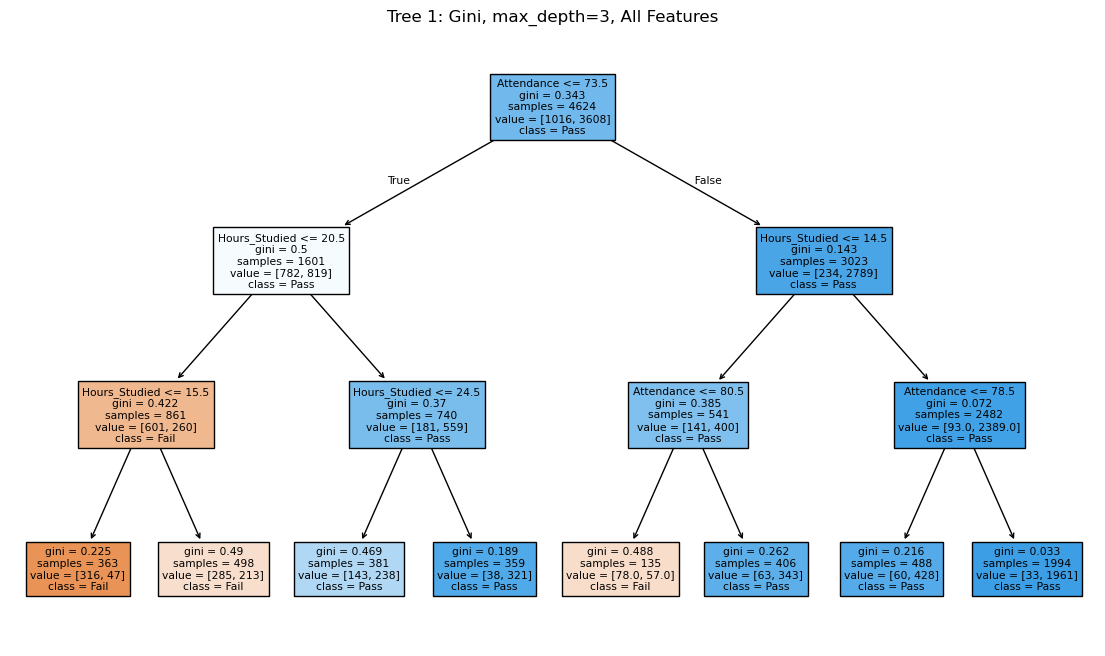

Tree 2 Accuracy: 0.843166918809884
Tree 2 Confusion Matrix:
 [[ 182  254]
 [  57 1490]]
Tree 2 root node: Previous_Scores


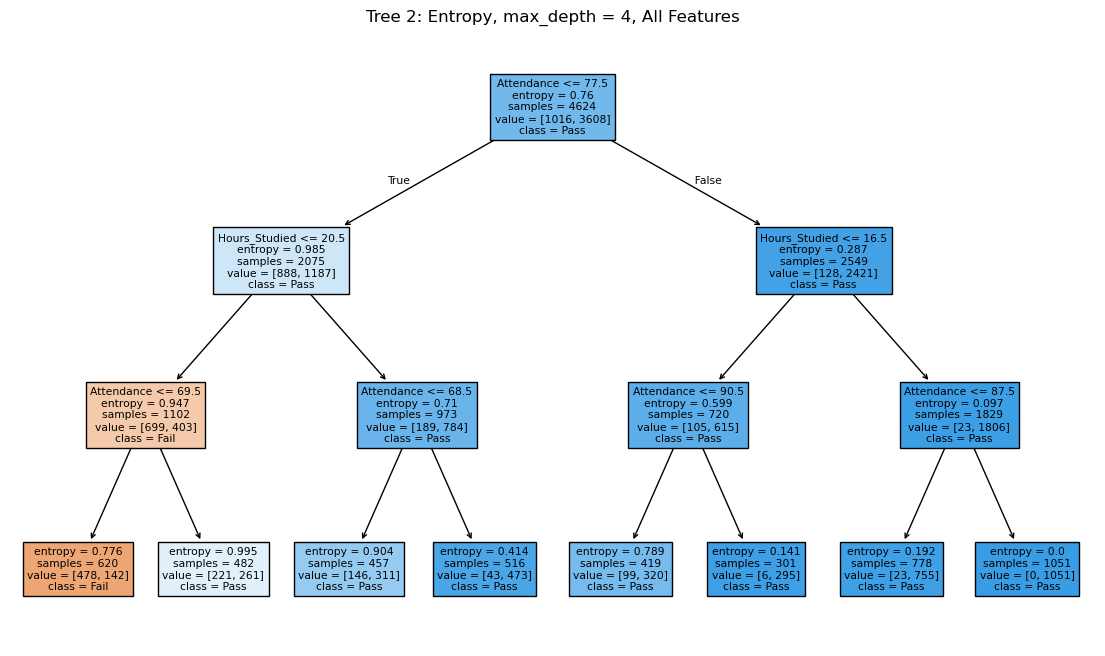

Accuracy: 0.8497226424609178
Confusion Matrix:
 [[ 270  166]
 [ 132 1415]]
Tree 3 root node: Attendance


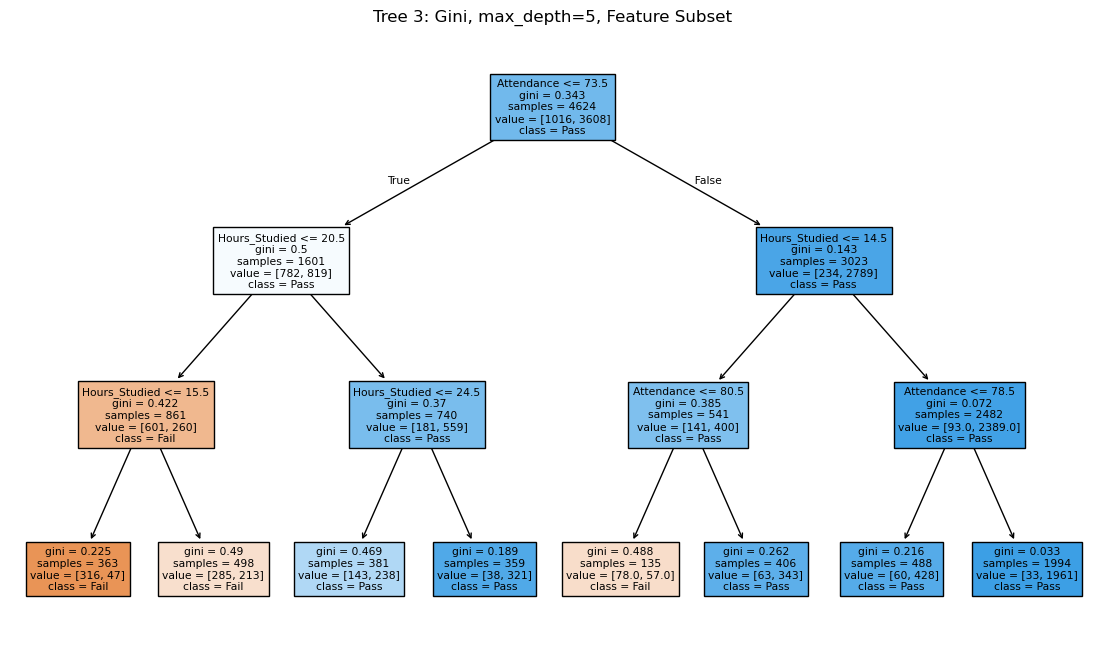

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Load data
df = pd.read_csv("C:/Users/User/Desktop/Machine Learning/dataset1_cleaned_numeric.csv")

# Create binary target
df["Pass"] = (df["Exam_Score"] >= 65).astype(int)

# Features and target
X = df.drop(["Exam_Score", "Pass"], axis=1)
y = df["Pass"]

# Split data
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# -----------------------------
# Tree 1
# -----------------------------
tree1 = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)
tree1.fit(x_train, y_train)
pred1 = tree1.predict(x_test)

print("Tree 1 Accuracy:", accuracy_score(y_test, pred1))
print("Tree 1 Confusion Matrix:\n", confusion_matrix(y_test, pred1))

print("Tree 1 root node:", X_subset.columns[tree1.tree_.feature[0]])

plt.figure(figsize=(14, 8))
plot_tree(tree1, feature_names=X.columns, class_names=["Fail", "Pass"], filled=True)
plt.title("Tree 1: Gini, max_depth=3, All Features")
plt.show()

# -----------------------------
# Tree 2
# -----------------------------
tree2 = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)
tree2.fit(x_train, y_train)
pred2 = tree2.predict(x_test)

print("Tree 2 Accuracy:", accuracy_score(y_test, pred2))
print("Tree 2 Confusion Matrix:\n", confusion_matrix(y_test, pred2))

print("Tree 2 root node:", X_subset.columns[tree2.tree_.feature[0]])

plt.figure(figsize=(14, 8))
plot_tree(tree2, feature_names=X.columns, class_names=["Fail", "Pass"], filled=True)
plt.title("Tree 2: Entropy, max_depth = 4, All Features")
plt.show()

# -----------------------------
# Tree 3: Gini, max_depth=5, Feature Subset
# -----------------------------

# Choose a subset of features
X_subset = df[["Attendance", "Previous_Scores", "Hours_Studied"]]
y = df["Pass"]

# Split the subset data
x_train_subset, x_test_subset, y_train_subset, y_test_subset = train_test_split(
    X_subset, y, test_size=0.3, random_state=42, stratify=y
)

# Train Tree 3
tree3 = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

tree3.fit(x_train_subset, y_train_subset)
pred3 = tree3.predict(x_test_subset)

# Results

print("Accuracy:", accuracy_score(y_test_subset, pred3))
print("Confusion Matrix:\n", confusion_matrix(y_test_subset, pred3))


# Root node
print("Tree 3 root node:", X_subset.columns[tree3.tree_.feature[0]])

# Plot the tree
plt.figure(figsize=(14, 8))
plot_tree(
    tree3,
    feature_names=X_subset.columns,
    class_names=["Fail", "Pass"],
    filled=True
)
plt.title("Tree 3: Gini, max_depth=5, Feature Subset")
plt.show()

In [8]:
plt.figure(figsize=(14, 8))
plot_tree(tree1, feature_names=X.columns, class_names=["Fail", "Pass"], filled=True)

plt.title("Tree 1: Gini, max_depth=3, All Features")
plt.savefig("tree1_gini_depth3_all_features.png")
plt.close()

plt.figure(figsize=(14, 8))
plot_tree(tree2, feature_names=X.columns, class_names=["Fail", "Pass"], filled=True)

plt.title("Tree 2: Entropy, max_depth=4, All Features")
plt.savefig("tree2_entropy_depth3_all_features.png")
plt.close()

plt.figure(figsize=(14, 8))
plot_tree(
    tree3,
    feature_names=X_subset.columns,
    class_names=["Fail", "Pass"],
    filled=True
)

plt.title("Tree 3: Gini, max_depth=3, Feature Subset")
plt.savefig("tree3_gini_depth5_subset.png")
plt.close()

In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Predictions
pred1 = tree1.predict(x_test)

# Accuracy
acc1 = accuracy_score(y_test, pred1)


# Confusion Matrix
cm1 = confusion_matrix(y_test, pred1)
print("Tree 1 Confusion Matrix:\n", cm1)

# Plot Confusion Matrix
plt.figure()
plt.imshow(cm1, cmap="Blues")
plt.title("Tree 1 Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Fail", "Pass"])
plt.yticks([0,1], ["Fail", "Pass"])

for i in range(len(cm1)):
    for j in range(len(cm1[0])):
        plt.text(j, i, cm1[i][j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("tree1_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.close()


pred2 = tree2.predict(x_test)

acc2 = accuracy_score(y_test, pred2)


cm2 = confusion_matrix(y_test, pred2)
print("Tree 2 Confusion Matrix:\n", cm2)

plt.figure()
plt.imshow(cm2, cmap="Blues")
plt.title("Tree 2 Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Fail", "Pass"])
plt.yticks([0,1], ["Fail", "Pass"])

for i in range(len(cm2)):
    for j in range(len(cm2[0])):
        plt.text(j, i, cm2[i][j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("tree2_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.close()


pred3 = tree3.predict(x_test_subset)

acc3 = accuracy_score(y_test_subset, pred3)


cm3 = confusion_matrix(y_test_subset, pred3)
print("Tree 3 Confusion Matrix:\n", cm3)

plt.figure()
plt.imshow(cm3, cmap="Blues")
plt.title("Tree 3 Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Fail", "Pass"])
plt.yticks([0,1], ["Fail", "Pass"])

for i in range(len(cm3)):
    for j in range(len(cm3[0])):
        plt.text(j, i, cm3[i][j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("tree3_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.close()

print("\nAccuracies: ")
print("Tree 1 Accuracy:", acc1)
print("Tree 2 Accuracy:", acc2)
print("Tree 3 Accuracy:", acc3)

Tree 1 Confusion Matrix:
 [[ 270  166]
 [ 132 1415]]
Tree 2 Confusion Matrix:
 [[ 182  254]
 [  57 1490]]
Tree 3 Confusion Matrix:
 [[ 270  166]
 [ 132 1415]]

Accuracies: 
Tree 1 Accuracy: 0.8497226424609178
Tree 2 Accuracy: 0.843166918809884
Tree 3 Accuracy: 0.8497226424609178


In [12]:
print("Tree 1 features used:", set(tree1.tree_.feature))
print("Tree 3 features used:", set(tree3.tree_.feature))

Tree 1 features used: {np.int64(0), np.int64(1), np.int64(-2)}
Tree 3 features used: {np.int64(0), np.int64(2), np.int64(-2)}
